# Product Recommendation System

## Import Libraries

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

## Data Collection

In [3]:
df = pd.read_csv("Product_Recommendation_System.csv",encoding='latin1')

### Basic Inspection
display(df.head(5))
display(df.shape)
display(df.columns)
display(df.info())
display(df.describe())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


(541909, 8)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


None

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Preprocessing

In [4]:
df = df.dropna(subset=['CustomerID'])
df = df.dropna(subset=['Description'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df = df[~df['InvoiceNo'].str.contains('C', na=False)]
df["CustomerID"] = df["CustomerID"].astype(int)

## Feature Engineering 

In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Hour'] = df['InvoiceDate'].dt.hour
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

## DATA VISUALIZATION / EDA

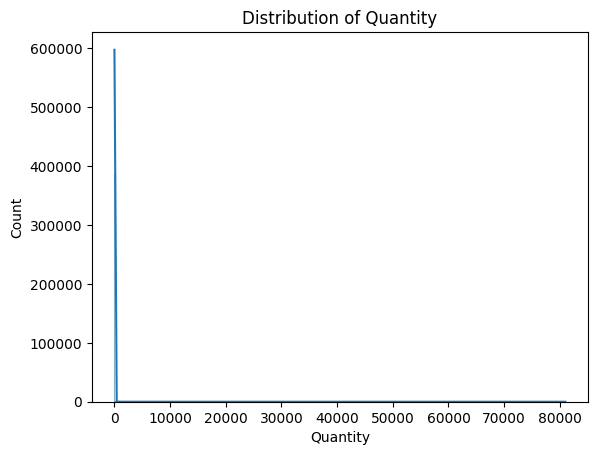

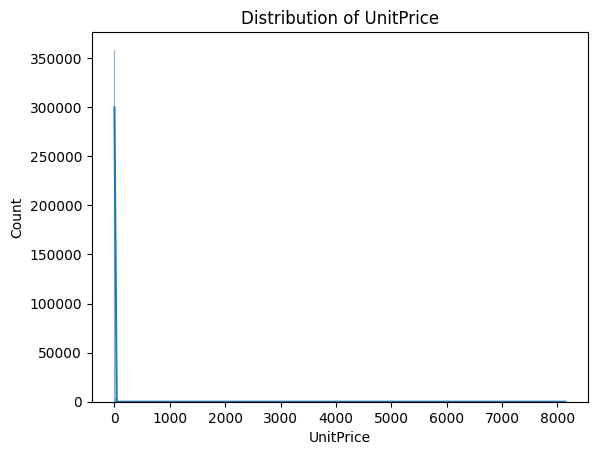

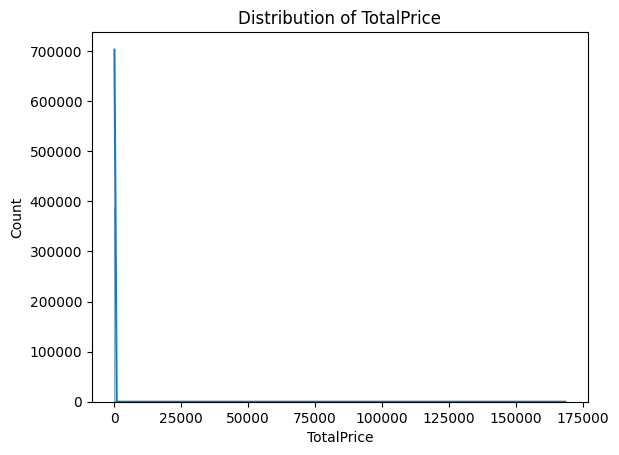

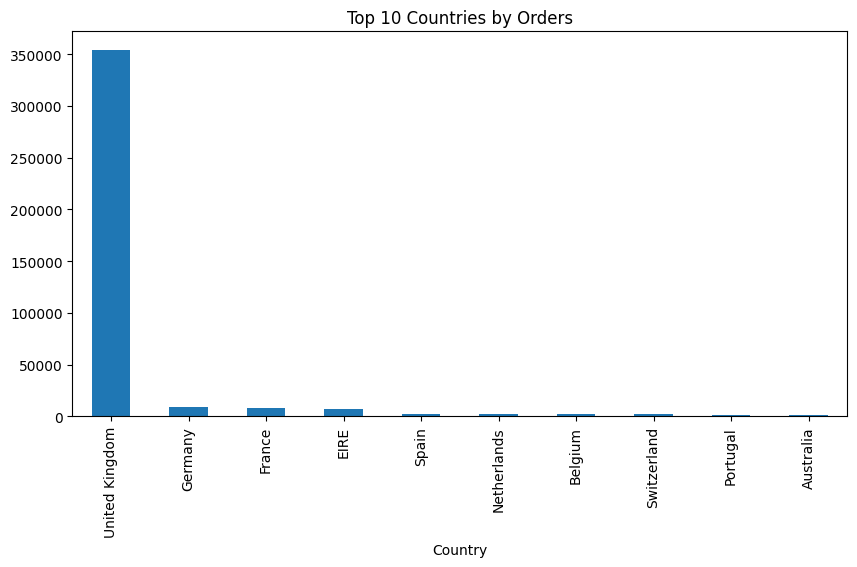

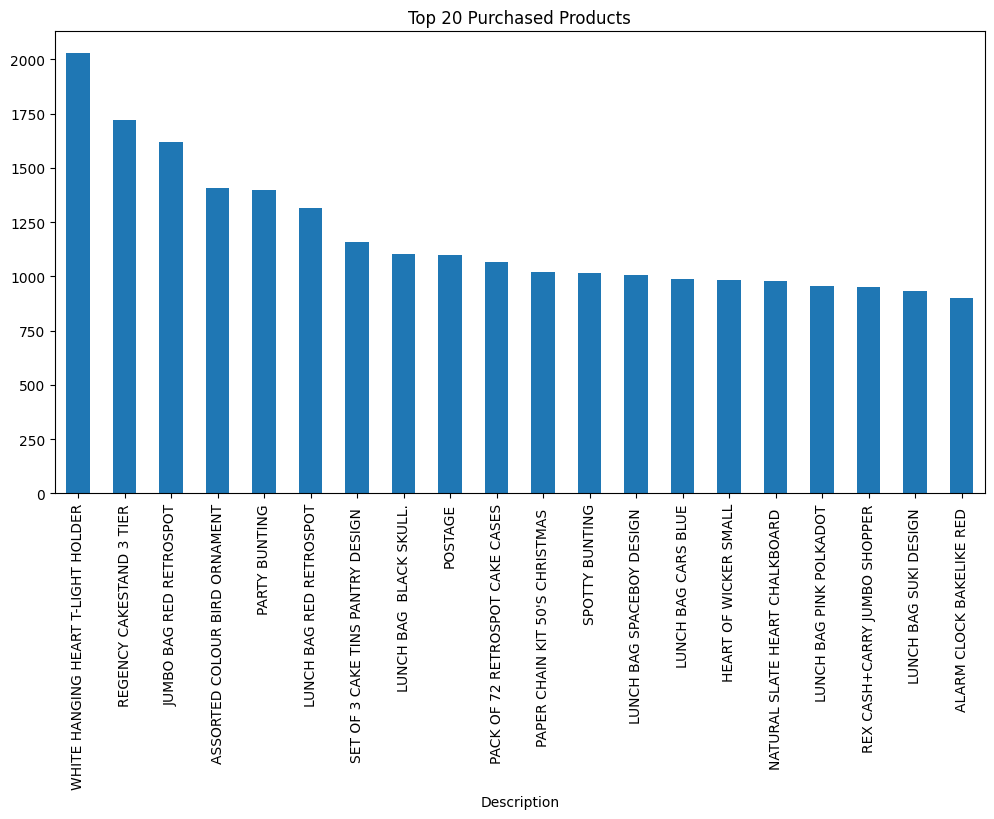

In [6]:
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

### UNIVARIATE ANALYSIS
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Top Countries
plt.figure(figsize=(10,5))
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries by Orders')
plt.show()

# Top Products
plt.figure(figsize=(12,6))
df['Description'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Purchased Products')
plt.show()

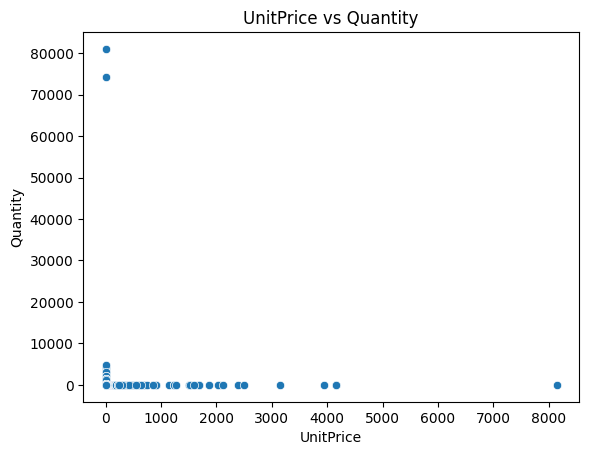

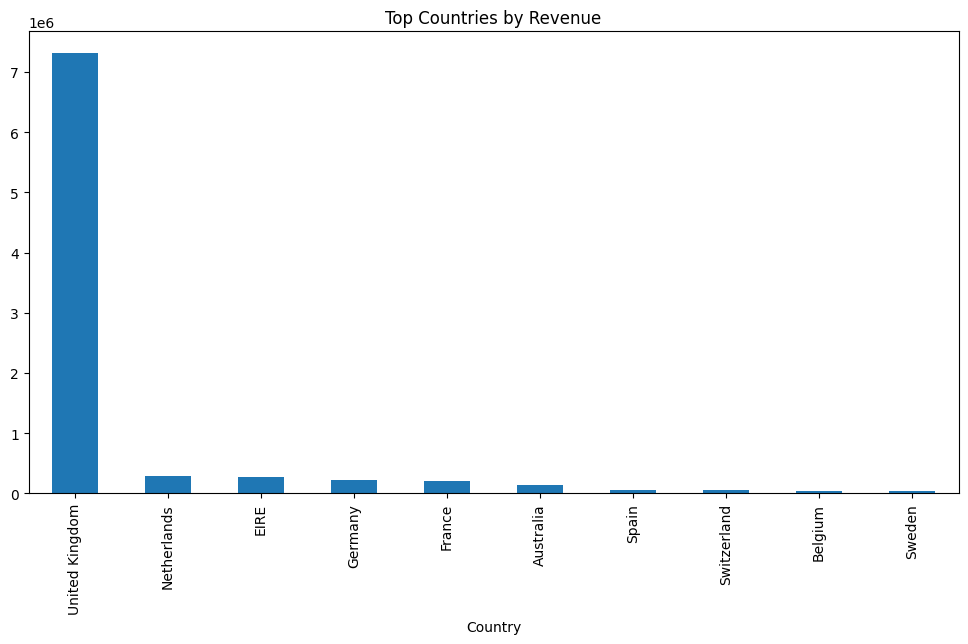

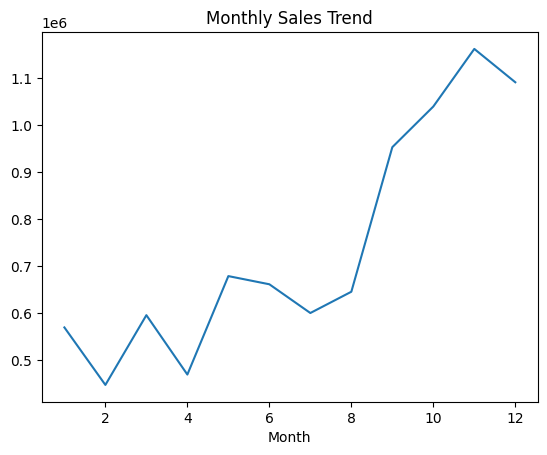

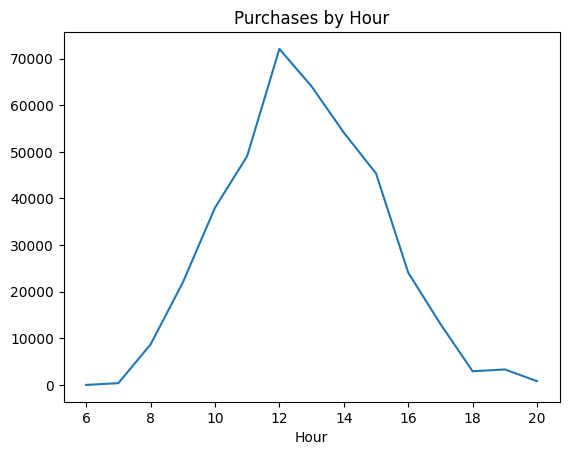

In [7]:
### MULTIVARIATE ANALYSIS

# Quantity vs Price
plt.figure()
sns.scatterplot(x='UnitPrice', y='Quantity', data=df)
plt.title('UnitPrice vs Quantity')
plt.show()

# Country vs Total Sales
country_sales = (df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(12,6))
country_sales.plot(kind='bar')
plt.title('Top Countries by Revenue')
plt.show()

# Monthly Sales Trend
monthly_sales = (df.groupby('Month')['TotalPrice'].sum())
plt.figure()
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.show()

# Hourly Purchase Trend
hour_sales = (df.groupby('Hour')['InvoiceNo'].count())
plt.figure()
hour_sales.plot()
plt.title('Purchases by Hour')
plt.show()

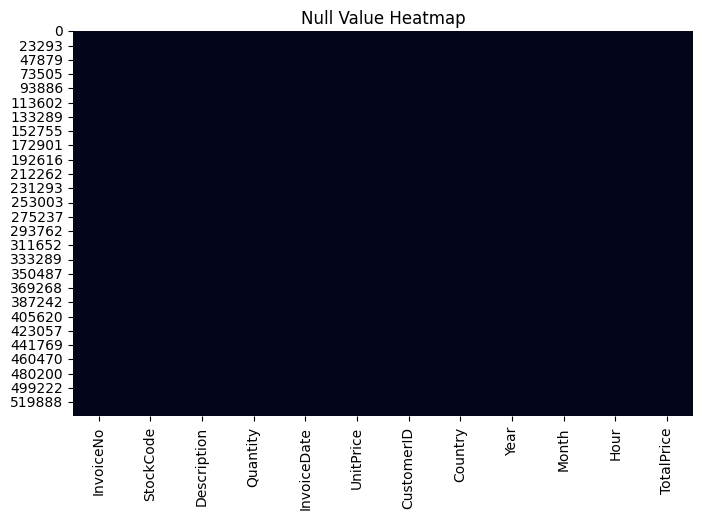

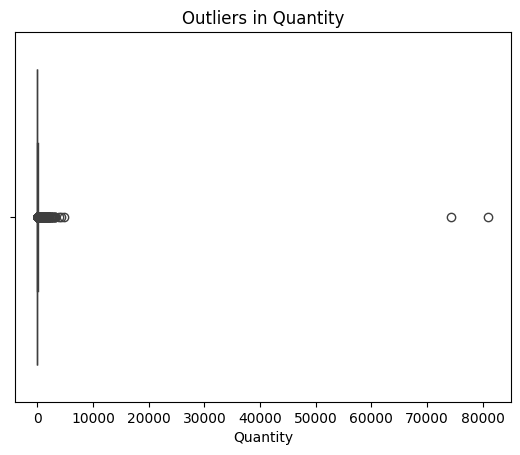

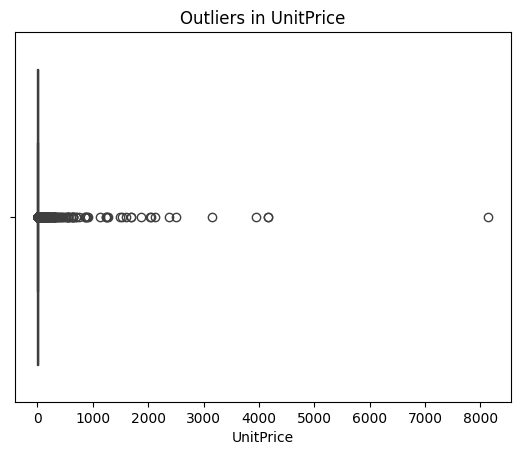

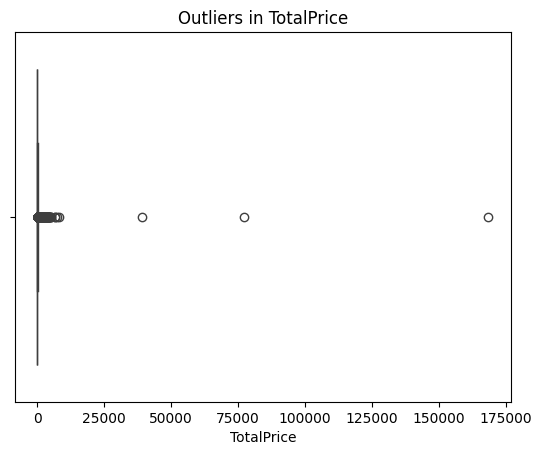

Outliers per column:
Quantity      388
UnitPrice     221
TotalPrice    344
dtype: int64


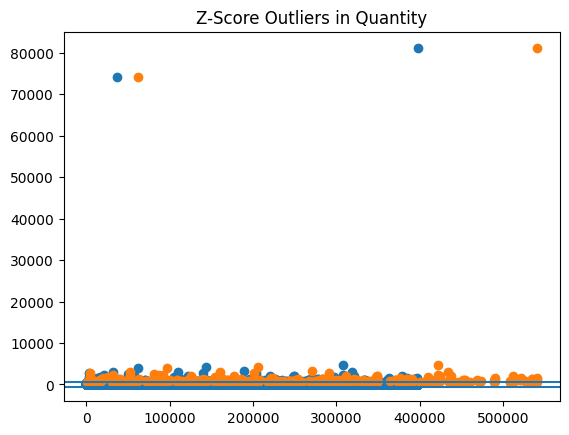

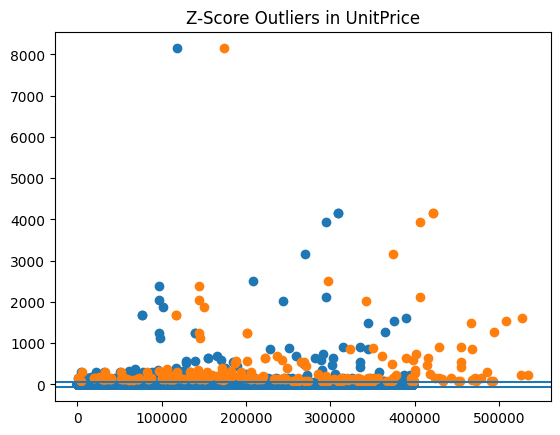

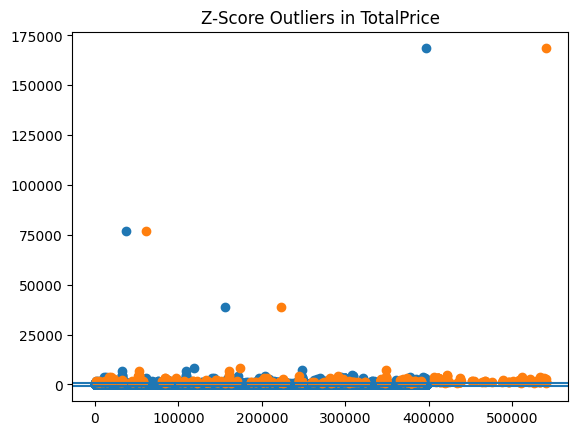

In [8]:
### MISSING VALUE HEATMAP
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(),cbar=False)
plt.title('Null Value Heatmap')
plt.show()

### OUTLIER DETECTION
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.show()

# Z-Score Outlier Detection
def detect_outliers_zscore(data, threshold=3):
    
    z_scores = np.abs((data - data.mean()) / data.std())
    return z_scores > threshold


z_outliers = detect_outliers_zscore(df[num_cols])
print("Outliers per column:")
print(z_outliers.sum())

# Outlier Scatter Plot
for col in num_cols:
    mean = df[col].mean()
    std = df[col].std()

    upper = mean + 3 * std
    lower = mean - 3 * std

    outliers = df[(df[col] > upper) | (df[col] < lower)]
    plt.figure()
    
    plt.scatter(range(len(df)), df[col])
    plt.scatter(outliers.index, outliers[col])

    plt.axhline(upper)
    plt.axhline(lower)

    plt.title(f'Z-Score Outliers in {col}')
    plt.show()

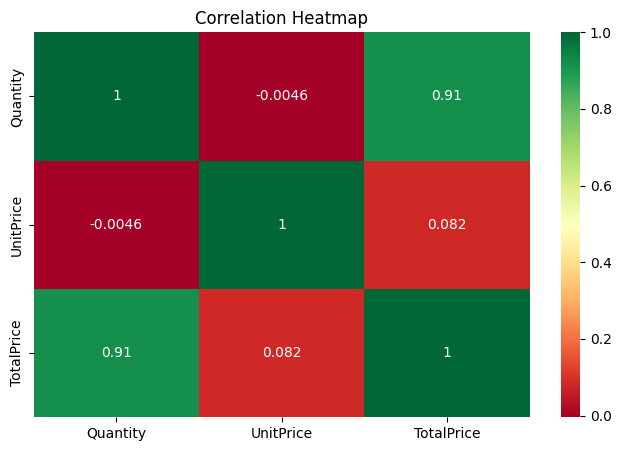

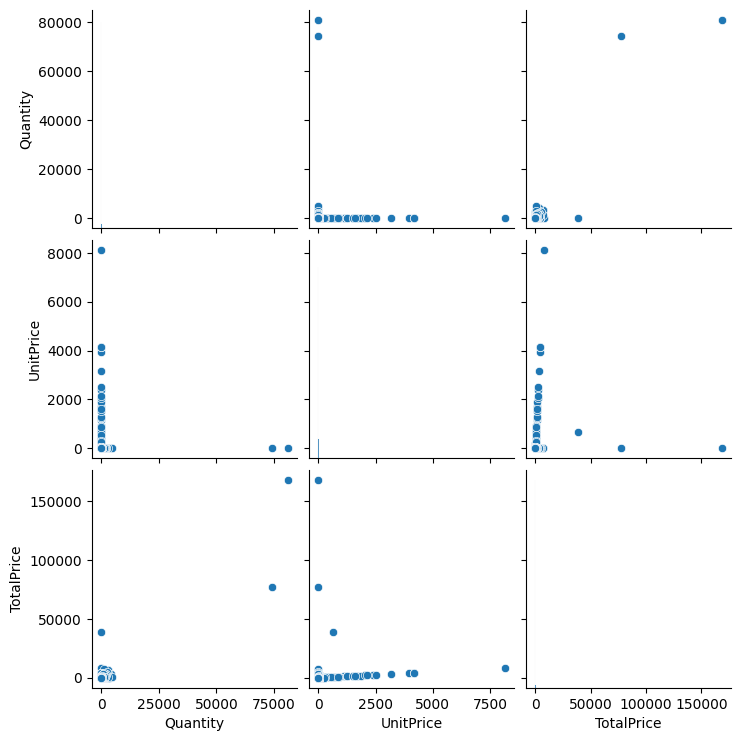

In [9]:
### CORRELATION MATRIX
plt.figure(figsize=(8,5))
corr = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.show()


# Pairplot
sns.pairplot(df[['Quantity', 'UnitPrice', 'TotalPrice']])
plt.show()

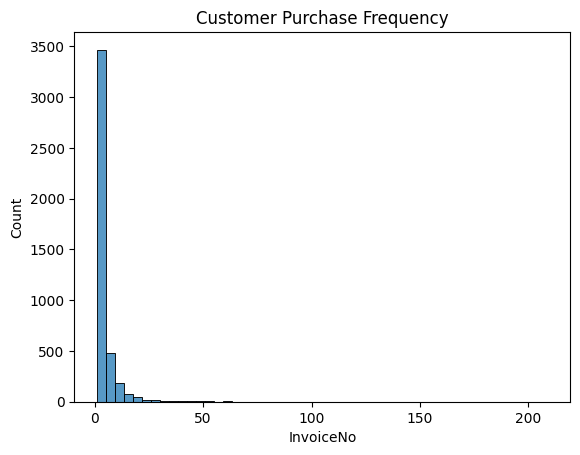

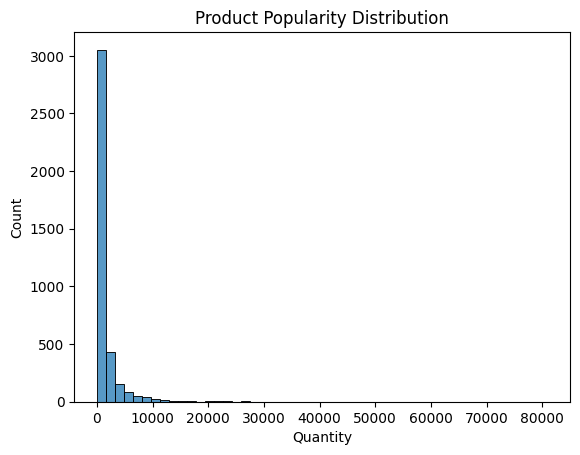

In [10]:
# Customer Purchase Distribution
customer_orders = (df.groupby('CustomerID')['InvoiceNo'].nunique())
plt.figure()
sns.histplot(customer_orders,bins=50)
plt.title('Customer Purchase Frequency')
plt.show()

# Product Popularity Distribution
product_sales = (df.groupby('Description')['Quantity'].sum())
plt.figure()
sns.histplot(product_sales,bins=50)
plt.title('Product Popularity Distribution')
plt.show()

## Train Test Split

In [11]:
df = df.sort_values("InvoiceDate")
train_size = int(len(df) * 0.80)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(train_df.shape)
print(test_df.shape)

(318307, 12)
(79577, 12)


## Model Training

### Popularity Recommendation

In [12]:
popular_products = (
    train_df
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

def popularity_recommend(n=10):
    return popular_products[:n]

### Collaborative Recommendation

In [13]:
# USER ITEM MATRIX
user_item = train_df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

#### User Based Collaborative Recommendation

In [14]:
user_similarity = cosine_similarity(user_item)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item.index,
    columns=user_item.index
)

def user_based_recommend(customer_id, top_n=10):
    if customer_id not in user_item.index:
        return []

    similar_users = (
        user_similarity_df[customer_id]
        .sort_values(ascending=False)
        .iloc[1:6]
        .index
    )

    purchased = (user_item.loc[customer_id])
    purchased = (purchased[purchased > 0].index)

    scores = {}
    for user in similar_users:
        items = user_item.loc[user]
        for product in items[items > 0].index:
            if product not in purchased:
                scores[product] = (scores.get(product, 0) + items[product])

    scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [x[0] for x in scores[:top_n]]

#### Item Based Collaborative Recommendation

In [15]:
item_similarity = cosine_similarity(user_item.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item.columns,
    columns=user_item.columns
)

def item_based_recommend(product, top_n=10):
    if product not in item_similarity_df.index:
        return []

    return (
        item_similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
        .index
        .tolist()
    )

### Content Based Recommendation

In [16]:
product_data = (train_df[['Description']].drop_duplicates().reset_index(drop=True))

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(product_data['Description'])

content_similarity = cosine_similarity(tfidf_matrix)

content_similarity_df = pd.DataFrame(
    content_similarity,
    index=product_data['Description'],
    columns=product_data['Description']
)

def content_recommend(product,top_n=10):
    if product not in content_similarity_df.index:
        return []

    return (
        content_similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
        .index
        .tolist()
    )

### Hybrid Recommendation

In [17]:
def hybrid_recommend(product, top_n=10):
    
    if (product not in item_similarity_df.index or product not in content_similarity_df.index):
        return []

    hybrid_score = (item_similarity_df[product] * 0.6 + content_similarity_df[product] * 0.4)

    return (
        hybrid_score
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
        .index
        .tolist()
    )

In [18]:
print("POPULARITY:", popularity_recommend(), "\n")
print("USER BASED:", user_based_recommend(17850), "\n")
print("ITEM BASED: ", item_based_recommend('WHITE HANGING HEART T-LIGHT HOLDER'), "\n")
print("CONTENT BASED:", content_recommend('WHITE HANGING HEART T-LIGHT HOLDER'), "\n")
print("HYBRID", hybrid_recommend('WHITE HANGING HEART T-LIGHT HOLDER'))

POPULARITY: ['MEDIUM CERAMIC TOP STORAGE JAR', 'WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'JUMBO BAG RED RETROSPOT', 'WHITE HANGING HEART T-LIGHT HOLDER', 'PACK OF 72 RETROSPOT CAKE CASES', 'ASSORTED COLOUR BIRD ORNAMENT', 'MINI PAINT SET VINTAGE ', 'PACK OF 60 PINK PAISLEY CAKE CASES', 'PACK OF 12 LONDON TISSUES ', 'BROCADE RING PURSE '] 

USER BASED: ['RED HANGING HEART T-LIGHT HOLDER', 'PLEASE ONE PERSON METAL SIGN', 'PINK POLKADOT WRAP ', 'WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'DECORATIVE WICKER HEART SMALL', 'HANGING CLEAR MINI BOTTLE', 'T-LIGHT HOLDER SWEETHEART HANGING', 'WOOD BLACK BOARD ANT WHITE FINISH', 'COOK WITH WINE METAL SIGN ', 'JUMBO BAG TOYS '] 

ITEM BASED:  ['GIN + TONIC DIET METAL SIGN', 'FAIRY CAKE FLANNEL ASSORTED COLOUR', 'TEA TIME TEA TOWELS ', 'DOORMAT FAIRY CAKE', 'RED HANGING HEART T-LIGHT HOLDER', 'WASHROOM METAL SIGN', 'LAUNDRY 15C METAL SIGN', 'HEART OF WICKER LARGE', 'HEART OF WICKER SMALL', 'GREEN VINTAGE SPOT BEAKER'] 

CONTENT BASED: ['PINK HANGING HEART T-LI

### Model Evaluation

In [19]:
ground_truth = (
    test_df
    .groupby("CustomerID")["Description"]
    .apply(set)
    .to_dict()
)

K = 10
popularity_dict = {}
user_cf_dict = {}
item_cf_dict = {}
content_dict = {}
hybrid_dict = {}

for user in ground_truth.keys():
    popularity_dict[user] = (popularity_recommend(K))

    if user not in user_item.index:
        continue

    user_cf_dict[user] = (user_based_recommend(user, K))
    purchased = (user_item.loc[user])

    purchased = (
        purchased[purchased > 0]
        .index
        .tolist()
    )

    item_recs = []
    content_recs = []
    hybrid_recs = []

    for product in purchased[:3]:

        item_recs.extend(item_based_recommend(product, K))
        content_recs.extend(content_recommend(product, K))
        hybrid_recs.extend(hybrid_recommend(product, K))

    item_cf_dict[user] = (list(dict.fromkeys(item_recs))[:K])
    content_dict[user] = (list(dict.fromkeys(content_recs))[:K])
    hybrid_dict[user] = (list(dict.fromkeys(hybrid_recs))[:K])


# Performance Metrics 

test_user_items = (
    test_df.groupby("CustomerID")["Description"]
    .apply(set)
    .to_dict()
)
all_products = set(df["Description"].unique())

def precision_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    if len(recommended) == 0:
        return 0

    hits = len(set(recommended) & set(relevant))
    return hits / len(recommended)


def recall_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    if len(relevant) == 0:
        return 0

    hits = len(set(recommended) & set(relevant))
    return hits / len(relevant)


def f1_at_k(recommended, relevant, k=10):
    p = precision_at_k(recommended, relevant, k)
    r = recall_at_k(recommended, relevant, k)

    if p + r == 0:
        return 0

    return 2 * p * r / (p + r)


def hit_rate_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    return int(len(set(recommended) & set(relevant)) > 0)


def average_precision(recommended, relevant, k=10):
    score = 0
    hits = 0

    for i,item in enumerate(recommended[:k], start=1):
        if item in relevant:
            hits += 1
            score += hits / i

    if hits == 0:
        return 0

    return score / min(len(relevant), k)


def map_at_k(all_recommendations, ground_truth, k=10):
    scores = []
    for user, recs in all_recommendations.items():
        if user in ground_truth:
            ap = average_precision(recs, ground_truth[user], k)
            scores.append(ap)

    return np.mean(scores)


def ndcg_at_k(recommended, relevant, k=10):
    dcg = 0
    for i,item in enumerate(recommended[:k], start=1):
        if item in relevant:
            dcg += 1 / np.log2(i + 1)

    ideal_hits = min(len(relevant), k)
    idcg = sum(1 / np.log2(i + 1) for i in range(1, ideal_hits + 1))

    if idcg == 0:
        return 0

    return dcg / idcg


def coverage(all_recommendations):
    recommended_items = set()
    for recs in all_recommendations.values():
        recommended_items.update(recs)

    return (len(recommended_items) / len(all_products))


def diversity(recommended_items, similarity_matrix):
    if len(recommended_items) < 2:
        return 0

    distances = []
    for i in range(len(recommended_items)):
        for j in range(i+1, len(recommended_items)):

            item1 = recommended_items[i]
            item2 = recommended_items[j]
            sim = similarity_matrix.loc[item1, item2]

            distances.append(1 - sim)

    return np.mean(distances)


def personalization(all_recommendations):
    users = list(all_recommendations.keys())
    similarities = []

    for i in range(len(users)):
        for j in range(i+1, len(users)):

            rec1 = set(all_recommendations[users[i]])
            rec2 = set(all_recommendations[users[j]])
            union = len(rec1 | rec2)

            if union == 0:
                continue

            sim = len(rec1 & rec2) / union
            similarities.append(sim)

    if len(similarities) == 0:
        return 0

    return 1 - np.mean(similarities)

def evaluate_model(name, recommendations):
    precisions = []
    recalls = []
    f1s = []
    hits = []
    ndcgs = []


    for user,recs in recommendations.items():

        if user not in ground_truth:
            continue

        relevant = ground_truth[user]

        precisions.append(precision_at_k(recs, relevant, K))
        recalls.append(recall_at_k(recs, relevant, K))
        f1s.append(f1_at_k(recs, relevant, K))
        hits.append(hit_rate_at_k(recs, relevant, K))
        ndcgs.append(ndcg_at_k(recs, relevant, K))

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Precision@10 :", np.mean(precisions))
    print("Recall@10    :", np.mean(recalls))
    print("F1@10        :", np.mean(f1s))
    print("HitRate@10   :", np.mean(hits))
    print("MAP@10       :", map_at_k(recommendations, ground_truth, K))
    print("NDCG@10      :", np.mean(ndcgs))
    print("Coverage     :", coverage(recommendations))
    print("Personalization :", personalization(recommendations))



evaluate_model("Popularity", popularity_dict)
evaluate_model("User CF", user_cf_dict)
evaluate_model("Item CF", item_cf_dict)
evaluate_model("Content Based", content_dict)
evaluate_model("Hybrid", hybrid_dict)


Popularity
Precision@10 : 0.05476445396145611
Recall@10    : 0.021844025331632502
F1@10        : 0.024539162938542743
HitRate@10   : 0.38329764453961457
MAP@10       : 0.019468514654255704
NDCG@10      : 0.05412766371912467
Coverage     : 0.0025793139025019345
Personalization : 0.0

User CF
Precision@10 : 0.028951317887627802
Recall@10    : 0.011219861521648748
F1@10        : 0.013437967114934822
HitRate@10   : 0.1969796454366382
MAP@10       : 0.01286635006742173
NDCG@10      : 0.03148951624585292
Coverage     : 0.4083053907660562
Personalization : 0.9893972116537872

Item CF
Precision@10 : 0.026263952724885097
Recall@10    : 0.01416018897783236
F1@10        : 0.013751840943804704
HitRate@10   : 0.1799080761654629
MAP@10       : 0.014606635643241028
NDCG@10      : 0.03246620971012677
Coverage     : 0.3574929068867681
Personalization : 0.9717274478662181

Content Based
Precision@10 : 0.04103742613263296
Recall@10    : 0.02079472826826015
F1@10        : 0.021053871520193387
HitRate@10 

In [23]:
# ==========================================================
# 16. SAVE MODELS
# ==========================================================

item_similarity_df.index = item_similarity_df.index.astype(object)
item_similarity_df.columns = item_similarity_df.columns.astype(object)

content_similarity_df.index = content_similarity_df.index.astype(object)
content_similarity_df.columns = content_similarity_df.columns.astype(object)

joblib.dump(popular_products, "model_popular.pkl")
joblib.dump(user_similarity_df, "model_cf_user.pkl")
joblib.dump(item_similarity_df, "model_cf_item.pkl")
joblib.dump(content_similarity_df, "model_content.pkl")
hybrid_model = {"item_similarity": item_similarity_df, "content_similarity": content_similarity_df, "item_weight": 0.6, "content_weight": 0.4}
joblib.dump(hybrid_model, "model_hybrid.pkl")
print("\n All Models Saved")


 All Models Saved
